# 04 – Augmentation and Hyperparameter Tuning

In this notebook, we extend the pretrained encoder from the previous notebook by experimenting with:

- Learning rate
- MAE vs SSIM loss weighting (`mae_weight`)
- Bottleneck size
- Encoder freezing
- Data augmentation strength

The goal is to evaluate how these factors affect reconstruction performance and anomaly detection capability on the MVTec AD cable dataset.

## 1. Imports & Setup

In [ ]:
import sys
sys.path.insert(0, '../src')

import copy
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage
from utils import GROUND_TRUTH_DIR

from utils import set_seed, CHECKPOINTS_DIR
from dataset import get_dataloaders, get_eval_transform, get_train_transform
from models_pretrained import ResNetAutoencoder
from masking import (
    generate_cable_mask,
    masked_mae_loss,
    masked_ssim_loss,
    compute_masked_error_map,
)

from torchmetrics.functional import structural_similarity_index_measure
from sklearn.metrics import roc_auc_score as _roc_auc
from sklearn.metrics import precision_recall_curve as _prc
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_score, recall_score, f1_score,
    accuracy_score, balanced_accuracy_score,
    confusion_matrix
)

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_MASKING = False

# ImageNet stats for pretrained ResNet encoder inputs.
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)

def normalize_for_encoder(x):
    mean = IMAGENET_MEAN.to(x.device)
    std = IMAGENET_STD.to(x.device)
    return (x - mean) / std

print(f'Using device: {DEVICE}')
print(f'Background masking: {USE_MASKING}')

Using device: cuda
Background masking: False


# 2. Weight Initialization

In [2]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)     

# 3. Dataloaders

In [3]:
#BATCH_SIZE = 16
BATCH_SIZE = 32

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE, val_split=0.15, seed=42
)

n_train = len(train_loader.dataset)
n_val   = len(val_loader.dataset)
n_test  = len(test_loader.dataset)

print(f'Train samples : {n_train}')
print(f'Val   samples : {n_val}')
print(f'Test  samples : {n_test}')
print(f'Train + Val   : {n_train + n_val}  (expected 224)')

Train samples : 191
Val   samples : 33
Test  samples : 150
Train + Val   : 224  (expected 224)


In [4]:
# Inspect a batch shape
sample_batch = next(iter(train_loader))
print(f'Batch shape : {sample_batch.shape}')  # [16, 3, 256, 256]
print(f'Dtype       : {sample_batch.dtype}')
print(f'Min / Max   : {sample_batch.min():.3f} / {sample_batch.max():.3f}')

Batch shape : torch.Size([32, 3, 256, 256])
Dtype       : torch.float32
Min / Max   : 0.000 / 1.000


# 4. Loss Function

In [5]:
def compute_loss(output, target, mask=None, mae_weight=0.4):
    if USE_MASKING and mask is not None:
        mae  = masked_mae_loss(output, target, mask)
        ssim = masked_ssim_loss(output, target, mask)
    else:
        mae  = torch.nn.functional.l1_loss(output, target)
        ssim = 1.0 - structural_similarity_index_measure(output, target, data_range=1.0)

    loss = mae_weight * mae + (1 - mae_weight) * ssim
    return loss, mae, ssim

# 5. Training Model

In [6]:
def train_model_full(model, checkpoint_name, LR, MAE_WEIGHT=0.4, NUM_EPOCHS=50, PATIENCE=15):
    """Train model with masked MAE+SSIM loss and early stopping."""
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses, val_losses = [], []
    best_val_loss  = float('inf')
    best_epoch     = 0
    wait           = 0
    best_state     = copy.deepcopy(model.state_dict())

    for epoch in range(1, NUM_EPOCHS + 1):
        # --- Train ---
        model.train()
        running = 0.0
        running_mae = 0.0
        running_ssim = 0.0
        
        for imgs in train_loader:
            imgs = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            optimizer.zero_grad()
            recon = model(imgs_enc)

            mask = generate_cable_mask(imgs) if USE_MASKING else None

            loss, loss_mae, loss_ssim = compute_loss(
                recon, imgs, mask, MAE_WEIGHT
            )
            loss.backward()
            optimizer.step()

            running += loss.item() * imgs.size(0)
            running_mae += loss_mae.item() * imgs.size(0)
            running_ssim += loss_ssim.item() * imgs.size(0)

        train_loss = running / len(train_loader.dataset)
        train_mae  = running_mae / len(train_loader.dataset)
        train_ssim_d = running_ssim / len(train_loader.dataset)

        # --- Validate ---
        model.eval()
        running_val = 0.0
        running_val_mae = 0.0
        running_val_ssim = 0.0
        
        with torch.no_grad():
            for imgs in val_loader:
                imgs  = imgs.to(DEVICE)
                imgs_enc = normalize_for_encoder(imgs)
                recon = model(imgs_enc)
                mask = generate_cable_mask(imgs) if USE_MASKING else None
                
                v_loss, val_mae, val_ssim = compute_loss(
                    recon, imgs, mask, MAE_WEIGHT
                )

                running_val += v_loss.item() * imgs.size(0)
                running_val_mae += val_mae.item() * imgs.size(0)
                running_val_ssim += val_ssim.item() * imgs.size(0)

        val_loss = running_val / len(val_loader.dataset)
        val_mae  = running_val_mae / len(val_loader.dataset)
        val_ssim_d = running_val_ssim / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_epoch    = epoch
            wait          = 0
            best_state    = copy.deepcopy(model.state_dict())
        else:
            wait += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{checkpoint_name}] Epoch {epoch:3d}/{NUM_EPOCHS}  '
                  f'train_loss={train_loss:.6f}  val_loss={val_loss:.6f}')
            print(f'    components: train_mae={train_mae:.6f}, train_(1-ssim)={train_ssim_d:.6f}  '
                  f'val_mae={val_mae:.6f}, val_(1-ssim)={val_ssim_d:.6f}')

        if wait >= PATIENCE:
            print(f'Early stopping at epoch {epoch} '
                  f'(best epoch={best_epoch}, best_val={best_val_loss:.6f})')
            break

    model.load_state_dict(best_state)
    CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), CHECKPOINTS_DIR / checkpoint_name)
    print(f'Saved checkpoint -> {CHECKPOINTS_DIR / checkpoint_name}')
    return model, {'train': train_losses, 'val': val_losses}

## 6. Image-level Evaluation

### 6.1 Compute Anomaly Scores on Test Set

In [7]:
def compute_scores(model, loader_test, loader_val, MAE_WEIGHT=0.4):
    """Return (mae_scores, combined_scores, all_labels, val_combined_errors) arrays."""
    mae_scores, ssim_dissim_scores, all_labels = [], [], []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader_test:
            imgs  = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            recon = model(imgs_enc)

            if USE_MASKING:
                mask    = generate_cable_mask(imgs)
                px_err  = torch.abs(recon - imgs) * mask
                n_cable = mask.sum(dim=(1, 2, 3)) * imgs.shape[1]
                batch_mae = px_err.sum(dim=(1, 2, 3)) / (n_cable + 1e-8)
            else:
                batch_mae = torch.mean(torch.abs(recon - imgs), dim=(1, 2, 3))
            mae_scores.extend(batch_mae.cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                if USE_MASKING:
                    m_i    = generate_cable_mask(imgs[i:i+1])
                    ssim_i = structural_similarity_index_measure(
                        recon[i:i+1] * m_i, imgs[i:i+1] * m_i, data_range=1.0
                    ).item()
                else:
                    ssim_i = structural_similarity_index_measure(
                        recon[i:i+1], imgs[i:i+1], data_range=1.0
                    ).item()
                ssim_dissim_scores.append(1.0 - ssim_i)

            all_labels.extend(labels.tolist())

    mae_scores          = np.array(mae_scores)
    ssim_dissim_scores  = np.array(ssim_dissim_scores)
    combined_scores     = MAE_WEIGHT * mae_scores + (1.0 - MAE_WEIGHT) * ssim_dissim_scores
    all_labels          = np.array(all_labels)

    # Val-set combined errors for threshold calibration
    val_mae_list, val_ssim_list = [], []
    with torch.no_grad():
        for imgs in loader_val:
            imgs  = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            recon = model(imgs_enc)
            if USE_MASKING:
                mask    = generate_cable_mask(imgs)
                px_err  = torch.abs(recon - imgs) * mask
                n_cable = mask.sum(dim=(1, 2, 3)) * imgs.shape[1]
                b_mae   = px_err.sum(dim=(1, 2, 3)) / (n_cable + 1e-8)
            else:
                b_mae = torch.mean(torch.abs(recon - imgs), dim=(1, 2, 3))
            val_mae_list.extend(b_mae.cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                if USE_MASKING:
                    m_i = generate_cable_mask(imgs[i:i+1])
                    s_i = structural_similarity_index_measure(
                        recon[i:i+1] * m_i, imgs[i:i+1] * m_i, data_range=1.0
                    ).item()
                else:
                    s_i = structural_similarity_index_measure(
                        recon[i:i+1], imgs[i:i+1], data_range=1.0
                    ).item()
                val_ssim_list.append(1.0 - s_i)

    val_mae  = np.array(val_mae_list)
    val_ssim = np.array(val_ssim_list)
    val_combined = MAE_WEIGHT * val_mae + (1.0 - MAE_WEIGHT) * val_ssim

    return mae_scores, combined_scores, all_labels, val_combined


### 6.2 Full Test Set Evaluation (ROC-AUC, F1, etc.)

In [8]:
def full_test_eval(labels, combined_scores, val_combined,
                   tag='Model', QUANTILES=None,
                   SELECTION_POLICY='max-f1', MAX_FPR=0.1,
                   plot_ax=None):

#Evaluate test-level metrics and optionally plot ROC.
    if QUANTILES is None:
        QUANTILES = [0.2, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.97, 0.99]

    auc = roc_auc_score(labels, combined_scores)
    ap  = average_precision_score(labels, combined_scores)

    sweep_rows = []
    for q in QUANTILES:
        threshold = float(np.quantile(val_combined, q))
        preds = (combined_scores >= threshold).astype(int)

        prec = precision_score(labels, preds, zero_division=0)
        rec  = recall_score(labels, preds, zero_division=0)
        f1   = f1_score(labels, preds, zero_division=0)
        acc  = accuracy_score(labels, preds)
        bacc = balanced_accuracy_score(labels, preds)
        tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
        fpr_at_thr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
        fnr        = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

        sweep_rows.append({
            'q': q, 'threshold': threshold,
            'f1': f1, 'rec': rec, 'prec': prec,
            'acc': acc, 'bacc': bacc,
            'fpr': fpr_at_thr, 'fnr': fnr,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        })

    if SELECTION_POLICY == 'fpr-constrained':
        feasible = [r for r in sweep_rows if r['fpr'] <= MAX_FPR]
        if feasible:
            selected = max(feasible, key=lambda r: (r['rec'], r['f1'], -r['threshold']))
        else:
            selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))
    else:
        selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))

    threshold = selected['threshold']
    results_dict = dict(
        auc=auc, ap=ap, f1=selected['f1'], rec=selected['rec'], prec=selected['prec'],
        acc=selected['acc'], bacc=selected['bacc'], fpr=selected['fpr'], fnr=selected['fnr'],
        tn=selected['tn'], fp=selected['fp'], fn=selected['fn'], tp=selected['tp'],
        threshold=threshold, quantile=selected['q'], policy=SELECTION_POLICY,
    )

    if plot_ax is not None:
        fpr_c, tpr_c, roc_thr = roc_curve(labels, combined_scores)
        plot_idx = np.argmin(np.abs(roc_thr - threshold))
        plot_ax.plot(fpr_c, tpr_c, label=f'ROC (AUC={auc:.3f})')
        plot_ax.scatter(fpr_c[plot_idx], tpr_c[plot_idx], color='red', zorder=5,
                        label=f'Selected thr ({threshold:.3f})')
        plot_ax.plot([0,1],[0,1],'k--', linewidth=0.8)
        plot_ax.set_xlabel('FPR')
        plot_ax.set_ylabel('TPR')
        plot_ax.set_title(f'ROC — {tag}')
        plot_ax.legend()

    # Print summary
    print(f'\n[{tag}] policy={SELECTION_POLICY}')
    print(f'  Selected quantile={selected["q"]:.2f}, threshold={threshold:.6f}')
    print(f'  ROC-AUC  : {auc:.4f}   PR-AUC: {ap:.4f}')
    print(f'  F1       : {selected["f1"]:.4f}   Recall: {selected["rec"]:.4f}   Precision: {selected["prec"]:.4f}')
    print(f'  Accuracy : {selected["acc"]:.4f}   Balanced: {selected["bacc"]:.4f}')
    print(f'  FPR      : {selected["fpr"]:.4f}   FNR: {selected["fnr"]:.4f}')
    print(f'  Confusion: TN={selected["tn"]}  FP={selected["fp"]}  FN={selected["fn"]}  TP={selected["tp"]}')
    print('  Sweep (q, F1, Recall, Precision, FPR):')
    for r in sweep_rows:
        print(f'    q={r["q"]:.2f}  f1={r["f1"]:.4f}  rec={r["rec"]:.4f}  prec={r["prec"]:.4f}  fpr={r["fpr"]:.4f}')

    return results_dict, sweep_rows

## 7. Pixel-level Evaluation

Per-pixel error maps are computed for both models; we report pixel AUROC and mean IoU (sweep over threshold candidates). Overlay visualisation uses the best-performing model.

In [9]:
eval_tf = get_eval_transform()

def pixel_eval(model, tag):
    dataset = test_loader.dataset
    pixel_scores_all, pixel_gt_all = [], []
    err_maps, gt_masks_256 = [], []

    model.eval()
    with torch.no_grad():
        for idx in range(len(dataset)):
            img_path, label = dataset.samples[idx]
            if label == 0:
                continue

            category  = img_path.parent.name
            stem      = img_path.stem
            mask_path = GROUND_TRUTH_DIR / category / f'{stem}_mask.png'

            img_t = eval_tf(PILImage.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
            img_t_enc = normalize_for_encoder(img_t)
            recon = model(img_t_enc)

            if USE_MASKING:
                cable_mask = generate_cable_mask(img_t)
                err_map    = compute_masked_error_map(recon, img_t, cable_mask)
            else:
                err_map = torch.mean(torch.abs(recon - img_t), dim=1).squeeze(0).cpu().numpy()

            gt_raw = np.array(
                PILImage.open(mask_path).convert('L').resize((256, 256), PILImage.NEAREST)
            )
            gt_bin = (gt_raw > 127).astype(np.uint8)

            err_maps.append(err_map)
            gt_masks_256.append(gt_bin)
            pixel_scores_all.extend(err_map.ravel())
            pixel_gt_all.extend(gt_bin.ravel())

    pixel_scores_all = np.array(pixel_scores_all)
    pixel_gt_all     = np.array(pixel_gt_all)

    px_auc = _roc_auc(pixel_gt_all, pixel_scores_all)

    _, _, px_thr = _prc(pixel_gt_all, pixel_scores_all)
    candidates = px_thr[::max(1, len(px_thr) // 200)]
    best_thr, best_miou = 0.0, -1.0
    for thr in candidates:
        ious = []
        for em, gt in zip(err_maps, gt_masks_256):
            pred  = (em >= thr).astype(np.uint8)
            inter = int((pred & gt).sum())
            union = int((pred | gt).sum())
            ious.append(inter / (union + 1e-8))
        m = float(np.mean(ious))
        if m > best_miou:
            best_miou, best_thr = m, float(thr)

    per_image_ious = []
    for em, gt in zip(err_maps, gt_masks_256):
        pred  = (em >= best_thr).astype(np.uint8)
        inter = int((pred & gt).sum())
        union = int((pred | gt).sum())
        per_image_ious.append(inter / (union + 1e-8))
    per_image_ious = np.array(per_image_ious)

    print(f'[{tag}]  Pixel AUROC: {px_auc:.4f}  '
          f'Optimal threshold: {best_thr:.6f}  '
          f'Mean IoU: {per_image_ious.mean():.4f}  '
          f'Std IoU: {per_image_ious.std():.4f}')

    return err_maps, gt_masks_256, per_image_ious, best_thr, px_auc

# 8. Summary Comparison

In [14]:
def print_summary(test_results, pixel_results=None):
    """
    test_results  : dict of {tag: results_dict} from full_test_eval
    pixel_results : dict of {tag: (pixel_auroc, mean_iou)} from pixel_eval
    """
    # Header
    col_width = 36 
    header_tags = list(test_results.keys())
    header = f"{'Metric':<22}" + ''.join([f"{tag:>{col_width}}" for tag in header_tags])
    print(header)
    print('-' * (22 + col_width *  len(header_tags)))

    metrics = [
        ('ROC-AUC', 'auc'),
        ('PR-AUC', 'ap'),
        ('F1', 'f1'),
        ('Recall', 'recall'),
        ('Precision', 'precision'),
        ('Accuracy', 'accuracy'),
        ('Balanced Acc','bacc'),
        ('Threshold', 'reference_threshold'),
        ('FPR', 'fpr'),
        ('FNR', 'fnr'),
    ]

    for label, key in metrics:
        row = f"{label:<22}"
        for tag in header_tags:
            val = test_results[tag].get(key, None)
            if val is None:
                row += f"{'N/A':>{col_width}}"
            else:
                row += f"{val:>{col_width}.4f}"
        print(row)

    # Pixel-level metrics if provided
    if pixel_results is not None:
        print('-' * (22 + col_width * len(header_tags)))
        for metric_name in ['Pixel AUROC', 'Mean IoU']:
            row = f"{metric_name:<22}"
            for tag in header_tags:
                if tag not in pixel_results:
                    row += f"{'N/A':>{col_width}}"
                else:
                    if metric_name == 'Pixel AUROC':
                        val = pixel_results[tag][0]
                    else:
                        val = pixel_results[tag][1]
                    row += f"{val:>{col_width}.4f}"
            print(row)

# 9. Tuning Experiments

In [11]:
def run_experiment(cfg):
    print(f"\nRunning: {cfg['name']}")

    model = ResNetAutoencoder(
        bottleneck_width=cfg['bottleneck'],
        freeze_encoder=cfg['freeze']
    ).to(DEVICE)

    model.bottleneck.apply(init_weights)
    model.decoder.apply(init_weights)

    model, losses = train_model_full(
        model,
        checkpoint_name=f"{cfg['name']}.pth",
        LR=cfg['lr'],  # matches train_model_full
        MAE_WEIGHT=cfg.get('mae_weight', 0.4),
        NUM_EPOCHS=cfg.get('num_epochs', 50),
        PATIENCE=cfg.get('patience', 15)
    )

    # --- Evaluation ---
    mae, comb, labels, val_comb = compute_scores(model, test_loader, val_loader)

    auc = roc_auc_score(labels, comb)
    ap  = average_precision_score(labels, comb)

    print(f"[{cfg['name']}] ROC-AUC={auc:.4f}, PR-AUC={ap:.4f}")

    # Determine threshold (example: mean of validation scores)
    reference_threshold = val_comb.mean()
    y_pred = (comb > reference_threshold).astype(int)

    # Other metrics
    prec = precision_score(labels, y_pred)
    rec  = recall_score(labels, y_pred)
    f1   = f1_score(labels, y_pred)
    acc  = accuracy_score(labels, y_pred)
    bacc = balanced_accuracy_score(labels, y_pred)

    # Confusion matrix for FPR and FNR
    tn, fp, fn, tp = confusion_matrix(labels, y_pred).ravel()
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    print(f"[{cfg['name']}] ROC-AUC={auc:.4f}, PR-AUC={ap:.4f}, "
          f"Reference_threshold={reference_threshold:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, "
          f"F1={f1:.4f}, Accuracy={acc:.4f}, Balanced Acc={bacc:.4f}, FPR={fpr:.4f}, FNR={fnr:.4f}")

    return {
        'name': cfg['name'],
        'model': model,
        'losses': losses,
        'metrics': {
            'auc': auc,
            'ap': ap,
            'reference_threshold': reference_threshold,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'accuracy': acc,
            'bacc': bacc,
            'fpr': fpr,
            'fnr': fnr
        }
    }


In [12]:
from itertools import product

lrs = [1e-4, 1e-3]
mae_weights = [0.4, 0.6]
bottlenecks = [128, 256]
freezes = [False, True]

configs = []
for lr, mae, bneck, freeze in product(lrs, mae_weights, bottlenecks, freezes):
    name = f"lr{lr}_mae{mae}_b{bneck}_freeze{freeze}"
    configs.append({
        'name': name,
        'lr': lr,
        'mae_weight': mae,
        'bottleneck': bneck,
        'freeze': freeze,
        'num_epochs': 50,
        'patience': 15
    })

print(f"Total configs: {len(configs)}")

Total configs: 16


In [ ]:
'''
configs = [ {'name': 'baseline', 'lr': 1e-4, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'higher_lr', 'lr': 1e-3, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'strong_mae', 'lr': 1e-4, 'mae_weight': 0.6, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'small_bottleneck', 'lr': 1e-4, 'mae_weight': 0.4, 'bottleneck': 128, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'freeze_encoder', 'lr': 1e-4, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15}, 
            ]
'''
configs = [ {'name': 'best_no_aug', 'lr': 1e-3, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15, 'aug': False},
            {'name': 'best_with_aug', 'lr': 1e-3, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15, 'aug': True}
            ]

In [13]:
import pickle

results = []

for cfg in configs:
    res = run_experiment(cfg)
    results.append(res)

test_results = {r['name']: r['metrics'] for r in results}
with open('test_results.pkl', 'wb') as f:
    pickle.dump(test_results, f)

print("Test results saved to test_results.pkl")
print_summary(test_results)


Running: lr0.0001_mae0.4_b128_freezeFalse


C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[lr0.0001_mae0.4_b128_freezeFalse.pth] Epoch   1/50  train_loss=0.671201  val_loss=0.517353
    components: train_mae=0.226703, train_(1-ssim)=0.967533  val_mae=0.186773, val_(1-ssim)=0.737740
[lr0.0001_mae0.4_b128_freezeFalse.pth] Epoch  10/50  train_loss=0.488202  val_loss=0.463187
    components: train_mae=0.215809, train_(1-ssim)=0.669797  val_mae=0.191283, val_(1-ssim)=0.644457
[lr0.0001_mae0.4_b128_freezeFalse.pth] Epoch  20/50  train_loss=0.476784  val_loss=0.465883
    components: train_mae=0.208931, train_(1-ssim)=0.655352  val_mae=0.193712, val_(1-ssim)=0.647331
[lr0.0001_mae0.4_b128_freezeFalse.pth] Epoch  30/50  train_loss=0.464919  val_loss=0.447066
    components: train_mae=0.191692, train_(1-ssim)=0.647070  val_mae=0.176798, val_(1-ssim)=0.627245
[lr0.0001_mae0.4_b128_freezeFalse.pth] Epoch  40/50  train_loss=0.457060  val_loss=0.441121
    components: train_mae=0.180975, train_(1-ssim)=0.641117  val_mae=0.168329, val_(1-ssim)=0.622982
[lr0.0001_mae0.4_b128_freezeFalse.p

C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[lr0.0001_mae0.4_b128_freezeTrue.pth] Epoch   1/50  train_loss=0.696474  val_loss=0.521231
    components: train_mae=0.279779, train_(1-ssim)=0.974271  val_mae=0.201537, val_(1-ssim)=0.734361
[lr0.0001_mae0.4_b128_freezeTrue.pth] Epoch  10/50  train_loss=0.537093  val_loss=0.530863
    components: train_mae=0.228379, train_(1-ssim)=0.742902  val_mae=0.212020, val_(1-ssim)=0.743425
[lr0.0001_mae0.4_b128_freezeTrue.pth] Epoch  20/50  train_loss=0.498326  val_loss=0.478006
    components: train_mae=0.210370, train_(1-ssim)=0.690296  val_mae=0.189355, val_(1-ssim)=0.670440
[lr0.0001_mae0.4_b128_freezeTrue.pth] Epoch  30/50  train_loss=0.480815  val_loss=0.461565
    components: train_mae=0.198465, train_(1-ssim)=0.669048  val_mae=0.178452, val_(1-ssim)=0.650306
[lr0.0001_mae0.4_b128_freezeTrue.pth] Epoch  40/50  train_loss=0.468393  val_loss=0.449270
    components: train_mae=0.190389, train_(1-ssim)=0.653728  val_mae=0.170277, val_(1-ssim)=0.635266
[lr0.0001_mae0.4_b128_freezeTrue.pth] Ep

...

[lr0.001_mae0.6_b128_freezeTrue.pth] Epoch   1/50  train_loss=0.519201  val_loss=0.421414
    components: train_mae=0.257568, train_(1-ssim)=0.911649  val_mae=0.201060, val_(1-ssim)=0.751946
[lr0.001_mae0.6_b128_freezeTrue.pth] Epoch  10/50  train_loss=0.356552  val_loss=0.345494
    components: train_mae=0.172929, train_(1-ssim)=0.631988  val_mae=0.163502, val_(1-ssim)=0.618481
[lr0.001_mae0.6_b128_freezeTrue.pth] Epoch  20/50  train_loss=0.331505  val_loss=0.332217
    components: train_mae=0.148691, train_(1-ssim)=0.605725  val_mae=0.148082, val_(1-ssim)=0.608419
[lr0.001_mae0.6_b128_freezeTrue.pth] Epoch  30/50  train_loss=0.297527  val_loss=0.299997
    components: train_mae=0.132842, train_(1-ssim)=0.544555  val_mae=0.133976, val_(1-ssim)=0.549030
[lr0.001_mae0.6_b128_freezeTrue.pth] Epoch  40/50  train_loss=0.240172  val_loss=0.242655
    components: train_mae=0.098681, train_(1-ssim)=0.452409  val_mae=0.099885, val_(1-ssim)=0.456811
[lr0.001_mae0.6_b128_freezeTrue.pth] Epoch  5

C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[lr0.001_mae0.6_b256_freezeFalse.pth] Epoch   1/50  train_loss=0.465678  val_loss=0.676294
    components: train_mae=0.224150, train_(1-ssim)=0.827969  val_mae=0.463156, val_(1-ssim)=0.996000
[lr0.001_mae0.6_b256_freezeFalse.pth] Epoch  10/50  train_loss=0.346298  val_loss=0.344192
    components: train_mae=0.159949, train_(1-ssim)=0.625821  val_mae=0.152796, val_(1-ssim)=0.631287
[lr0.001_mae0.6_b256_freezeFalse.pth] Epoch  20/50  train_loss=0.244157  val_loss=0.258238
    components: train_mae=0.104613, train_(1-ssim)=0.453473  val_mae=0.112215, val_(1-ssim)=0.477273
[lr0.001_mae0.6_b256_freezeFalse.pth] Epoch  30/50  train_loss=0.175104  val_loss=0.174296
    components: train_mae=0.076831, train_(1-ssim)=0.322514  val_mae=0.076919, val_(1-ssim)=0.320360
[lr0.001_mae0.6_b256_freezeFalse.pth] Epoch  40/50  train_loss=0.126396  val_loss=0.123862
    components: train_mae=0.048991, train_(1-ssim)=0.242504  val_mae=0.047958, val_(1-ssim)=0.237718
[lr0.001_mae0.6_b256_freezeFalse.pth] Ep

C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[lr0.001_mae0.6_b256_freezeTrue.pth] Epoch   1/50  train_loss=0.489258  val_loss=0.428771
    components: train_mae=0.217635, train_(1-ssim)=0.896694  val_mae=0.190022, val_(1-ssim)=0.786895
[lr0.001_mae0.6_b256_freezeTrue.pth] Epoch  10/50  train_loss=0.348436  val_loss=0.336733
    components: train_mae=0.163242, train_(1-ssim)=0.626228  val_mae=0.153958, val_(1-ssim)=0.610895
[lr0.001_mae0.6_b256_freezeTrue.pth] Epoch  20/50  train_loss=0.324803  val_loss=0.329658
    components: train_mae=0.145609, train_(1-ssim)=0.593593  val_mae=0.146751, val_(1-ssim)=0.604019
[lr0.001_mae0.6_b256_freezeTrue.pth] Epoch  30/50  train_loss=0.248727  val_loss=0.247217
    components: train_mae=0.104225, train_(1-ssim)=0.465479  val_mae=0.102553, val_(1-ssim)=0.464214
[lr0.001_mae0.6_b256_freezeTrue.pth] Epoch  40/50  train_loss=0.194567  val_loss=0.195830
    components: train_mae=0.068721, train_(1-ssim)=0.383337  val_mae=0.070214, val_(1-ssim)=0.384255
[lr0.001_mae0.6_b256_freezeTrue.pth] Epoch  5

In [15]:
print_summary(test_results)

Metric                    lr0.0001_mae0.4_b128_freezeFalse     lr0.0001_mae0.4_b128_freezeTrue    lr0.0001_mae0.4_b256_freezeFalse     lr0.0001_mae0.4_b256_freezeTrue    lr0.0001_mae0.6_b128_freezeFalse     lr0.0001_mae0.6_b128_freezeTrue    lr0.0001_mae0.6_b256_freezeFalse     lr0.0001_mae0.6_b256_freezeTrue     lr0.001_mae0.4_b128_freezeFalse      lr0.001_mae0.4_b128_freezeTrue     lr0.001_mae0.4_b256_freezeFalse      lr0.001_mae0.4_b256_freezeTrue     lr0.001_mae0.6_b128_freezeFalse      lr0.001_mae0.6_b128_freezeTrue     lr0.001_mae0.6_b256_freezeFalse      lr0.001_mae0.6_b256_freezeTrue
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

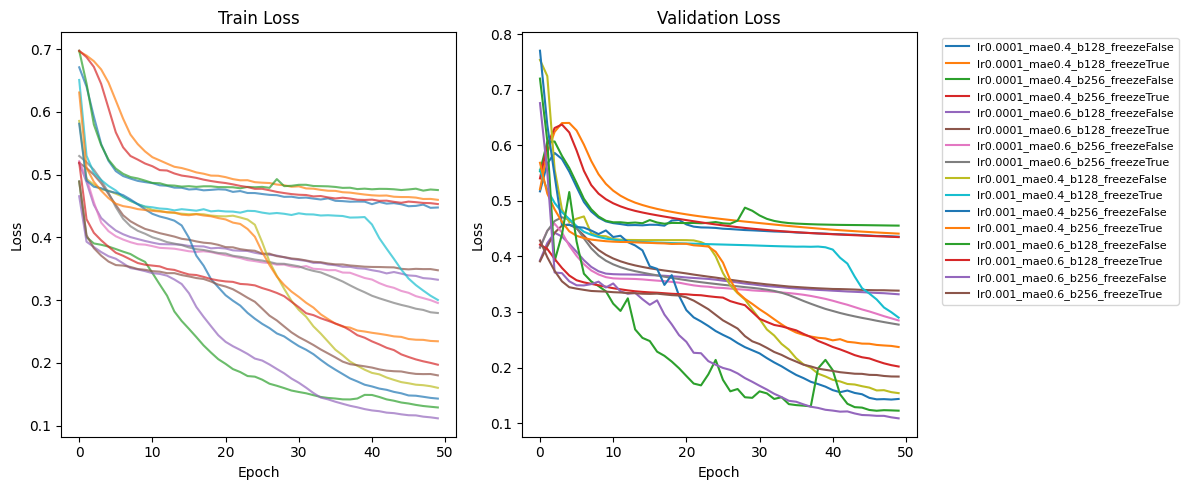

In [18]:
plt.figure(figsize=(12, 5))

# ---- TRAIN ----
plt.subplot(1, 2, 1)
for r in results:
    train_losses = r['losses']['train']
    plt.plot(train_losses, alpha=0.7)

plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# ---- VAL ----
plt.subplot(1, 2, 2)
for r in results:
    val_losses = r['losses']['val']
    plt.plot(val_losses, label=r['name'])

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Legend only for val
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# 10. Best Model Selection + Evaluation

In [28]:
# Define weights for each metric
metric_weights = {
    'auc': 0.30,   # ROC-AUC
    'ap': 0.30,    # PR-AUC
    'recall': 0.15,    # catching anomalies is mor impt
    'f1': 0.10,        
    'precision': 0.10, 
    'accuracy': 0.05   # minor weight due to class imbalance
}

# Compute a weighted score for each result
for r in results:
    metrics = r['metrics']
    weighted_score = sum(metrics[k] * w for k, w in metric_weights.items())
    r['weighted_score'] = weighted_score
    print(f"{r['name']:<40} Weighted Score: {weighted_score:.4f}")

# Select best model based on weighted score
best = max(results, key=lambda x: x['weighted_score'])
print(f"\nBest config: {best['name']} (Weighted Score={best['weighted_score']:.4f})")

best_model = best['model']

lr0.0001_mae0.4_b128_freezeFalse         Weighted Score: 0.5908
lr0.0001_mae0.4_b128_freezeTrue          Weighted Score: 0.6112
lr0.0001_mae0.4_b256_freezeFalse         Weighted Score: 0.5984
lr0.0001_mae0.4_b256_freezeTrue          Weighted Score: 0.5917
lr0.0001_mae0.6_b128_freezeFalse         Weighted Score: 0.6006
lr0.0001_mae0.6_b128_freezeTrue          Weighted Score: 0.6091
lr0.0001_mae0.6_b256_freezeFalse         Weighted Score: 0.6615
lr0.0001_mae0.6_b256_freezeTrue          Weighted Score: 0.7149
lr0.001_mae0.4_b128_freezeFalse          Weighted Score: 0.5697
lr0.001_mae0.4_b128_freezeTrue           Weighted Score: 0.7097
lr0.001_mae0.4_b256_freezeFalse          Weighted Score: 0.5445
lr0.001_mae0.4_b256_freezeTrue           Weighted Score: 0.7477
lr0.001_mae0.6_b128_freezeFalse          Weighted Score: 0.5791
lr0.001_mae0.6_b128_freezeTrue           Weighted Score: 0.6883
lr0.001_mae0.6_b256_freezeFalse          Weighted Score: 0.5647
lr0.001_mae0.6_b256_freezeTrue          

In [29]:
# Compute anomaly scores for test and val sets
mae_scores, combined_scores, all_labels, val_combined = compute_scores(
    best_model, test_loader, val_loader
)

n_normal = int((all_labels == 0).sum())
n_anom   = int((all_labels == 1).sum())
print(f'\nTest set: {n_normal} normal, {n_anom} anomalous')

best_model_name = best['name']
for tag, mae_s, comb_s in [(best_model_name, mae_scores, combined_scores)]:
    print(f'\nModel: [{tag}]')
    print(f'  MAE      — normal: {mae_s[all_labels==0].mean():.4f}, anom: {mae_s[all_labels==1].mean():.4f}')
    print(f'  Combined — normal: {comb_s[all_labels==0].mean():.4f}, anom: {comb_s[all_labels==1].mean():.4f}')

# Compute standard metrics using threshold from val set
threshold = val_combined.mean()
y_pred = (combined_scores > threshold).astype(int)

prec = precision_score(all_labels, y_pred)
rec  = recall_score(all_labels, y_pred)
f1   = f1_score(all_labels, y_pred)
acc  = accuracy_score(all_labels, y_pred)
bacc = balanced_accuracy_score(all_labels, y_pred)
roc  = roc_auc_score(all_labels, combined_scores)
ap   = average_precision_score(all_labels, combined_scores)

# Confusion matrix for FPR / FNR
tn, fp, fn, tp = confusion_matrix(all_labels, y_pred, labels=[0,1]).ravel()

fpr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

results_dict = {
    'auc': roc,
    'ap': ap,
    'f1': f1,
    'recall': rec,
    'precision': prec,
    'accuracy': acc,
    'bacc': bacc,
    'reference_threshold': threshold,
    'fpr': fpr,
    'fnr': fnr
}
metrics = [
    ('ROC-AUC', 'auc'),
    ('PR-AUC', 'ap'),
    ('F1', 'f1'),
    ('Recall', 'recall'),
    ('Precision', 'precision'),
    ('Accuracy', 'accuracy'),
    ('Balanced Acc','bacc'),
    ('Threshold', 'reference_threshold'),
    ('FPR', 'fpr'),
    ('FNR', 'fnr'),
]
print(f"\nMetrics (reference_threshold={threshold:.4f}):")
for name, key in metrics:
    print(f"  {name:<12}: {results_dict[key]:.4f}")

C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(



Test set: 58 normal, 92 anomalous

Model: [lr0.001_mae0.4_b256_freezeTrue]
  MAE      — normal: 0.0607, anom: 0.0647
  Combined — normal: 0.2205, anom: 0.2370

Metrics (reference_threshold=0.2369):
  ROC-AUC     : 0.7661
  PR-AUC      : 0.8409
  F1          : 0.6528
  Recall      : 0.5109
  Precision   : 0.9038
  Accuracy    : 0.6667
  Balanced Acc: 0.7123
  Threshold   : 0.2369
  FPR         : 0.0862
  FNR         : 0.4891


In [47]:
# Sweep quantiles and select threshold
QUANTILES = np.linspace(0.2, 0.99, 50)
SELECTION_POLICY = 'fpr-constrained'
MAX_FPR = 0.20

auc = roc_auc_score(all_labels, combined_scores)
ap  = average_precision_score(all_labels, combined_scores)

sweep_rows = []
for q in QUANTILES:
    threshold = float(np.quantile(val_combined, q))
    preds = (combined_scores >= threshold).astype(int)
    prec = precision_score(all_labels, preds, zero_division=0)
    rec  = recall_score(all_labels, preds, zero_division=0)
    f1   = f1_score(all_labels, preds, zero_division=0)
    acc  = accuracy_score(all_labels, preds)
    bacc = balanced_accuracy_score(all_labels, preds)
    tn, fp, fn, tp = confusion_matrix(all_labels, preds, labels=[0,1]).ravel()
    fpr_at_thr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
    fnr        = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

    sweep_rows.append({
        'q': q, 'threshold': threshold,
        'f1': f1, 'rec': rec, 'prec': prec,
        'acc': acc, 'bacc': bacc,
        'fpr': fpr_at_thr, 'fnr': fnr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    })

# Select best threshold
if SELECTION_POLICY == 'fpr-constrained':
    feasible = [r for r in sweep_rows if r['fpr'] <= MAX_FPR]
    if feasible:
        selected = max(feasible, key=lambda r: (r['rec'], r['f1'], -r['threshold']))
    else:
        selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))
else:
    selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))

threshold = selected['threshold']

print(f'Selected threshold: {threshold:.6f} (quantile={selected["q"]:.2f})')
print(f'ROC-AUC: {auc:.4f}, PR-AUC: {ap:.4f}')
print(f'F1={selected["f1"]:.4f}, Recall={selected["rec"]:.4f}, Precision={selected["prec"]:.4f}')
print(f'Accuracy={selected["acc"]:.4f}, Balanced Acc={selected["bacc"]:.4f}')
print(f'FPR={selected["fpr"]:.4f}, FNR={selected["fnr"]:.4f}')
print(f'Confusion: TN={selected["tn"]}, FP={selected["fp"]}, FN={selected["fn"]}, TP={selected["tp"]}')

Selected threshold: 0.232477 (quantile=0.36)
ROC-AUC: 0.7661, PR-AUC: 0.8409
F1=0.7089, Recall=0.6087, Precision=0.8485
Accuracy=0.6933, Balanced Acc=0.7181
FPR=0.1724, FNR=0.3913
Confusion: TN=48, FP=10, FN=36, TP=56


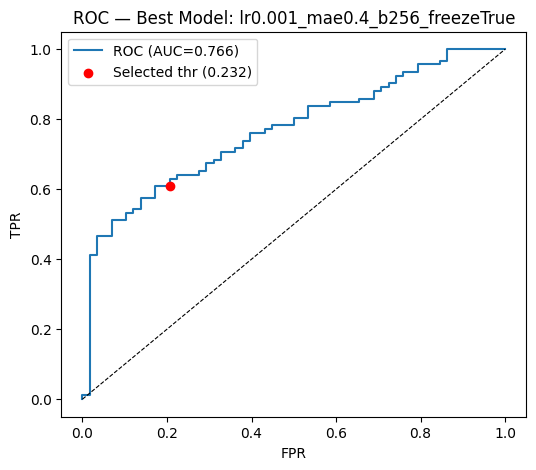

In [48]:
# Plot ROC curve
fpr_c, tpr_c, roc_thr = roc_curve(all_labels, combined_scores)
plot_idx = np.argmin(np.abs(roc_thr - threshold))

plt.figure(figsize=(6,5))
plt.plot(fpr_c, tpr_c, label=f'ROC (AUC={auc:.3f})')
plt.scatter(fpr_c[plot_idx], tpr_c[plot_idx], color='red', zorder=5,
            label=f'Selected thr ({threshold:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'ROC — Best Model: {best_model_name}')
plt.legend()
plt.show()


[lr0.001_mae0.4_b256_freezeTrue]  Pixel AUROC: 0.6947  Optimal threshold: 0.137434  Mean IoU: 0.1071  Std IoU: 0.0773


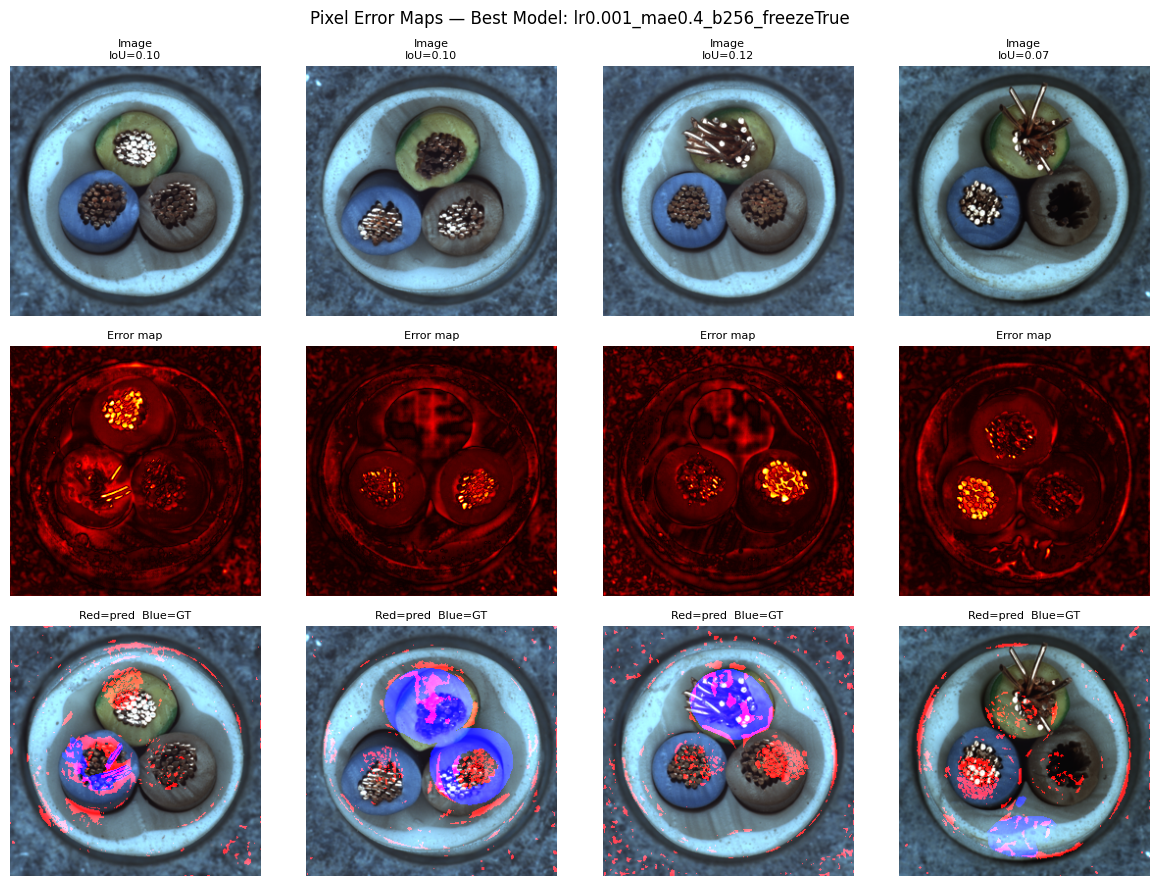

In [49]:
# Compute pixel-level maps
em_best, gt_best, iou_best, thr_best, px_auc = pixel_eval(best_model, best_model_name)

# Visualize a few images
n_vis = min(4, len(em_best))
vis_idx = np.linspace(0, len(em_best)-1, n_vis, dtype=int)

fig, axes = plt.subplots(3, n_vis, figsize=(3*n_vis, 9))
for col, vi in enumerate(vis_idx):
    orig = np.array(PILImage.open(test_loader.dataset.samples[vi][0]).convert('RGB').resize((256,256)))

    axes[0, col].imshow(orig)
    axes[0, col].set_title(f'Image\nIoU={iou_best[vi]:.2f}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(em_best[vi], cmap='hot')
    axes[1, col].set_title('Error map', fontsize=8)
    axes[1, col].axis('off')

    overlay = orig.copy()
    overlay[(em_best[vi] >= thr_best), 0] = 255  # Red = predicted anomaly
    overlay[gt_best[vi].astype(bool), 2] = 255   # Blue = ground truth
    axes[2, col].imshow(overlay)
    axes[2, col].set_title('Red=pred  Blue=GT', fontsize=8)
    axes[2, col].axis('off')

plt.suptitle(f'Pixel Error Maps — Best Model: {best_model_name}', fontsize=12)
plt.tight_layout()
plt.show()

In [50]:
# Summary table
print(f"{'Metric':<22} {'Value':>12}")
print('-'*35)
summary_metrics = [
    ('ROC-AUC', auc),
    ('PR-AUC', ap),
    ('F1', selected['f1']),
    ('Recall', selected['rec']),
    ('Precision', selected['prec']),
    ('Accuracy', selected['acc']),
    ('Balanced Acc', selected['bacc']),
    ('Threshold', selected['threshold']),
    ('FPR', selected['fpr']),
    ('FNR', selected['fnr']),
]
for label, value in summary_metrics:
    print(f'{label:<22} {value:>12.4f}')
print('-'*35)

Metric                        Value
-----------------------------------
ROC-AUC                      0.7661
PR-AUC                       0.8409
F1                           0.7089
Recall                       0.6087
Precision                    0.8485
Accuracy                     0.6933
Balanced Acc                 0.7181
Threshold                    0.2325
FPR                          0.1724
FNR                          0.3913
-----------------------------------


In [52]:
# Reference threshold metrics ---
ref_threshold = val_combined.mean()
y_pred_ref = (combined_scores > ref_threshold).astype(int)

prec_ref = precision_score(all_labels, y_pred_ref)
rec_ref  = recall_score(all_labels, y_pred_ref)
f1_ref   = f1_score(all_labels, y_pred_ref)
acc_ref  = accuracy_score(all_labels, y_pred_ref)
bacc_ref = balanced_accuracy_score(all_labels, y_pred_ref)
tn, fp, fn, tp = confusion_matrix(all_labels, y_pred_ref, labels=[0,1]).ravel()
fpr_ref = fp / (fp + tn)
fnr_ref = fn / (fn + tp)

# Optimized threshold metrics
opt_threshold = selected['threshold']
prec_opt = selected['prec']
rec_opt  = selected['rec']
f1_opt   = selected['f1']
acc_opt  = selected['acc']
bacc_opt = selected['bacc']
fpr_opt  = selected['fpr']
fnr_opt  = selected['fnr']

print(f"{'Metric':<22} {'Ref Thr.':>12} {'Optimized Thr.':>16}")
print('-'*52)

summary_metrics = [
    ('ROC-AUC', roc, roc),
    ('PR-AUC', ap, ap),
    ('F1', f1_ref, f1_opt),
    ('Recall', rec_ref, rec_opt),
    ('Precision', prec_ref, prec_opt),
    ('Accuracy', acc_ref, acc_opt),
    ('Balanced Acc', bacc_ref, bacc_opt),
    ('Threshold', ref_threshold, opt_threshold),
    ('FPR', fpr_ref, fpr_opt),
    ('FNR', fnr_ref, fnr_opt),
]

for label, ref_val, opt_val in summary_metrics:
    print(f"{label:<22} {ref_val:>12.4f} {opt_val:>16.4f}")

print('-'*52)

Metric                     Ref Thr.   Optimized Thr.
----------------------------------------------------
ROC-AUC                      0.7661           0.7661
PR-AUC                       0.8409           0.8409
F1                           0.6528           0.7089
Recall                       0.5109           0.6087
Precision                    0.9038           0.8485
Accuracy                     0.6667           0.6933
Balanced Acc                 0.7123           0.7181
Threshold                    0.2369           0.2325
FPR                          0.0862           0.1724
FNR                          0.4891           0.3913
----------------------------------------------------
